# GC Example 12: Globular Cluster Mass Function

**EPS Research — Milky Way GC Corpus v1.3.2**

The GC mass function is roughly log-normal peaked at ~2×10^5 Msun.
This turnover mass is a fossil record of dynamical evolution.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19907766  
**Sources:** Harris (1996/2010), Vasiliev & Baumgardt (2021), Baumgardt et al. (2023), Schiavon et al. (2024) APOGEE DR17  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'harris_gc_corpus_v1.3.2.jsonl': 'https://zenodo.org/records/21093446/files/harris_gc_corpus_v1.3.2.jsonl',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

clusters = []
with open('harris_gc_corpus_v1.3.2.jsonl') as f:
    for line in f:
        clusters.append(json.loads(line))
print(f"Total clusters: {len(clusters)}")


Total clusters: 174


Clusters with mass: 154
Mass range: 746 -- 3940000 Msun
Median mass: 147000 Msun
log median: 5.17


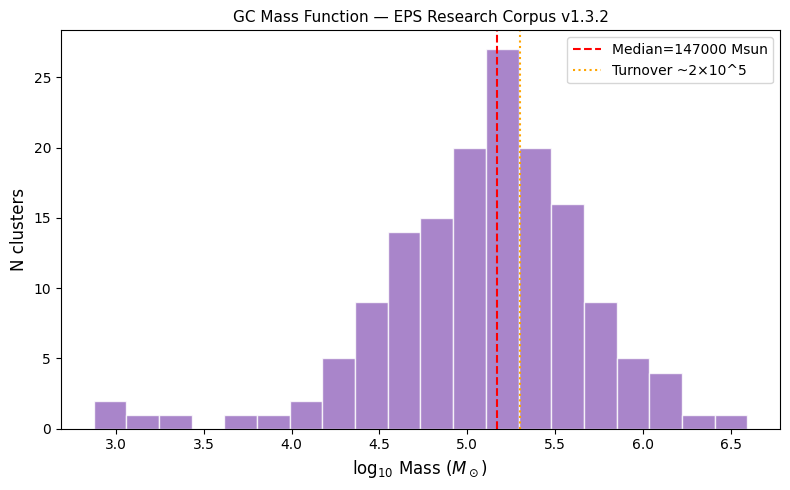

In [3]:
masses=[c['baumgardt2023']['mass_msun'] for c in clusters
        if c.get('baumgardt2023') and c['baumgardt2023'].get('mass_msun')]
print(f"Clusters with mass: {len(masses)}")
print(f"Mass range: {min(masses):.0f} -- {max(masses):.0f} Msun")
print(f"Median mass: {np.median(masses):.0f} Msun")
print(f"log median: {np.log10(np.median(masses)):.2f}")
fig,ax=plt.subplots(figsize=(8,5))
ax.hist(np.log10(masses),bins=20,color='#9467bd',alpha=0.8,edgecolor='white')
ax.axvline(np.log10(np.median(masses)),color='red',ls='--',lw=1.5,
           label=f'Median={np.median(masses):.0f} Msun')
ax.axvline(np.log10(2e5),color='orange',ls=':',lw=1.5,label='Turnover ~2×10^5')
ax.set_xlabel(r'log$_{10}$ Mass ($M_\odot$)',fontsize=12)
ax.set_ylabel('N clusters',fontsize=12)
ax.set_title('GC Mass Function — EPS Research Corpus v1.3.2',fontsize=11)
ax.legend(); plt.tight_layout()
plt.savefig('gc12_mass_function.png',dpi=150,bbox_inches='tight'); plt.show()